# Anomaly Detection & Pattern Discovery
**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus

**Goal:** Detect anomalies across the full train timeline, then cluster anomaly windows by their sensor activation profiles to discover recurring anomaly patterns. These patterns define the subsystem-aware feature groups for modeling.

**Approach:**
1. Compute per-sensor normal baselines from non-failure, non-maintenance periods
2. Score every 6-min window across the full timeline (z-score per sensor)
3. Flag anomalous windows and analyze their distribution
4. Build sensor activation profiles for anomalous windows
5. Cluster anomaly windows to discover recurring patterns
6. Map patterns to subsystems and prepare for expert verification

**Inputs:** Raw train parquet data  
**Outputs:** Recurring anomaly patterns (feature group definitions)

## 0. Imports & Setup

In [1]:
import sys, os, gc
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.config import (
    TRAIN_GLOB_PORTABLE as TRAIN_PATH,
    SUBSYSTEMS, ALL_SENSOR_COLS
)

plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['font.size'] = 11

# Reverse lookup: column -> subsystem
_col_to_subsystem = {col: ss for ss, cols in SUBSYSTEMS.items() for col in cols}
def get_subsystem(col):
    return _col_to_subsystem.get(col, 'Context')

META_COLS = ['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE',
             'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE',
             'year', 'month', 'day']

# Window parameters (same as Stefan's best config)
WINDOW_S = 350       # 6-min window (~5.83 min, matches Stefan's 350s)
ZSCORE_THRESHOLD = 3 # |z-score| above this = sensor is activated in that window
MIN_ROWS = int(WINDOW_S * 0.8)  # minimum rows per window (280 of 350)

print(f'Window size: {WINDOW_S}s ({WINDOW_S/60:.1f} min)')
print(f'Z-score threshold: {ZSCORE_THRESHOLD}')
print(f'Min rows per window: {MIN_ROWS}')
print('Setup done.')

Window size: 350s (5.8 min)
Z-score threshold: 3
Min rows per window: 280
Setup done.


## 1. Compute Normal Baselines (streaming)

We stream through all parquet files to compute per-sensor normal statistics (mean, std) from rows that are:
- NOT in a failure period
- NOT in a maintenance period

We use **Welford's online algorithm** to accumulate mean/std without loading all data at once.

In [2]:
# Stream through all parquet files to compute normal baselines
files = sorted(glob.glob(TRAIN_PATH, recursive=True))
print(f'Train parquet files: {len(files)}')

# First pass: determine sensor columns from first file
sample = pd.read_parquet(files[0])
sensor_cols = [c for c in sample.columns if c not in META_COLS]
print(f'Sensor columns: {len(sensor_cols)}')
del sample

# Accumulate sum and sum-of-squares for normal rows (online mean/std)
n_normal = np.zeros(len(sensor_cols))
col_sum = np.zeros(len(sensor_cols))
col_sum2 = np.zeros(len(sensor_cols))
n_total = 0

for i, f in enumerate(files):
    df = pd.read_parquet(f)
    n_total += len(df)
    normal_mask = ~df['TRAIN_IS_IN_FAILURE'] & ~df['TRAIN_IS_IN_MAINTENANCE']
    ndf = df.loc[normal_mask, sensor_cols]
    vals = ndf.values  # (n_rows, n_sensors)
    
    # Handle NaNs: count non-NaN per column
    valid = ~np.isnan(vals)
    n_normal += valid.sum(axis=0)
    col_sum += np.nansum(vals, axis=0)
    col_sum2 += np.nansum(vals**2, axis=0)
    
    del df, ndf, vals; gc.collect()
    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{len(files)}] processed...')

print(f'\nTotal rows: {n_total:,}')
print(f'Normal rows: {int(n_normal.mean()):,} ({100*n_normal.mean()/n_total:.1f}%)')

# Compute baselines
bl_mean = col_sum / n_normal
bl_var = (col_sum2 / n_normal) - bl_mean**2
bl_std = np.sqrt(np.maximum(bl_var, 0))
bl_std[bl_std < 1e-10] = 1.0  # constant sensors

baselines = {sensor_cols[i]: {'mean': float(bl_mean[i]), 'std': float(bl_std[i])} 
             for i in range(len(sensor_cols))}
baselines_df = pd.DataFrame(baselines).T
baselines_df['subsystem'] = [get_subsystem(c) for c in baselines_df.index]

print(f'Baselines computed for {len(baselines)} sensors')
print(f'Constant sensors (std set to 1.0): {(bl_std == 1.0).sum()}')
print(baselines_df.head(10).round(6).to_string())

Train parquet files: 246
Sensor columns: 101


  [50/246] processed...


  [100/246] processed...


  [150/246] processed...


  [200/246] processed...



Total rows: 14,342,361
Normal rows: 13,591,746 (94.8%)
Baselines computed for 101 sensors
Constant sensors (std set to 1.0): 1
                                            mean       std subsystem
CW1_PNEUMATIC_BRAKE_ACTIVE              0.529882  0.499106     Brake
MW2_PROPORTIONAL_VALVE_PRESSURE_BOGIE1  0.206172  0.214529     Brake
MW4_BRAKE_CYLINDER_PRESSURE_BOGIE1      0.164172  0.203439     Brake
CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1      0.075500  0.101678     Brake
CW2_COMPRESSOR_RUNNING                  0.327838  0.469425       APU
MW4_SPRING_BRAKE_PRESSURE_BOGIE2        0.660002  0.102442     Brake
MW3_SPRING_BRAKE_PRESSURE_BOGIE2        0.657457  0.129857     Brake
MW4_PROPORTIONAL_VALVE_PRESSURE_BOGIE2  0.199800  0.212256     Brake
MW1_SPRING_BRAKE_PRESSURE_BOGIE2        0.658447  0.104444     Brake
MW2_LOAD_PRESSURE_BOGIE2                0.247167  0.031913  Leveling


In [3]:
# Extract failure events by streaming through files
# Collect all failure rows (only 3 columns needed — very small)
fail_rows = []
for f in files:
    df = pd.read_parquet(f, columns=['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE'])
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    fail_rows.append(df[df['TRAIN_IS_IN_FAILURE']])
    del df

fail_df = pd.concat(fail_rows, ignore_index=True).sort_values('TIMESTAMP').reset_index(drop=True)
del fail_rows; gc.collect()

# Group consecutive failure rows into events
fail_df['_grp'] = (fail_df['TIMESTAMP'].diff() > pd.Timedelta(hours=1)).cumsum()
train_events = (
    fail_df.groupby('_grp')
    .agg(start=('TIMESTAMP', 'min'), end=('TIMESTAMP', 'max'),
         failure_type=('TRAIN_FAILURE_TYPE', 'first'), n_rows=('TIMESTAMP', 'count'))
    .reset_index(drop=True)
)
train_events.index = train_events.index + 1
train_events.index.name = 'event'
train_events['duration_h'] = (train_events['end'] - train_events['start']).dt.total_seconds() / 3600
del fail_df

print(f'Train failure events: {len(train_events)}')
print(train_events[['start', 'end', 'duration_h', 'failure_type']].to_string())

Train failure events: 16
                    start                 end  duration_h               failure_type
event                                                                               
1     2024-06-27 15:47:30 2024-06-27 17:52:28    2.082778       Brake System Failure
2     2024-08-19 10:37:51 2024-08-19 11:05:44    0.464722       Brake System Failure
3     2024-08-27 15:58:43 2024-08-27 19:32:21    3.560556    Leveling System Failure
4     2024-08-28 06:39:39 2024-08-28 12:05:51    5.436667    Leveling System Failure
5     2024-08-28 19:51:57 2024-08-28 21:29:25    1.624444    Leveling System Failure
6     2024-09-03 05:04:00 2024-09-03 07:33:36    2.493333       Brake System Failure
7     2024-09-22 05:49:43 2024-09-22 08:14:45    2.417222       Brake System Failure
8     2024-10-06 02:04:15 2024-10-06 11:15:18    9.184167       Brake System Failure
9     2024-10-06 20:44:32 2024-10-06 21:25:07    0.676389       Brake System Failure
10    2024-10-07 08:41:44 2024-10-07 11:

## 2. Compute Per-Window Z-Scores

Slide **non-overlapping 350s windows** across the full train timeline.  
For each window, compute the **mean** of every sensor, then z-score it against the normal baselines from Section 1.

A sensor is **activated** in a window if |z-score| > 3.

This gives us a (n_windows × n_sensors) z-score matrix — the foundation for anomaly detection.

In [4]:
# Stream through files again: compute per-window sensor means, z-scores, metadata
# Each file is one day (~50-80k rows), we process windows within each file

window_records = []

for i, f in enumerate(files):
    df = pd.read_parquet(f)
    df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
    df.sort_values('TIMESTAMP', inplace=True, ignore_index=True)
    
    if len(df) < MIN_ROWS:
        del df; continue
    
    # Assign window IDs within this file
    epoch = df['TIMESTAMP'].iloc[0]
    secs = (df['TIMESTAMP'] - epoch).dt.total_seconds().astype(np.int64)
    df['_win'] = secs // WINDOW_S
    
    for wid, wdf in df.groupby('_win'):
        if len(wdf) < MIN_ROWS:
            continue
        
        rec = {
            'win_start': wdf['TIMESTAMP'].iloc[0],
            'win_end': wdf['TIMESTAMP'].iloc[-1],
            'n_rows': len(wdf),
            'has_failure': bool(wdf['TRAIN_IS_IN_FAILURE'].any()),
            'has_maintenance': bool(wdf['TRAIN_IS_IN_MAINTENANCE'].any()),
        }
        
        # Failure type
        if rec['has_failure']:
            ft = wdf.loc[wdf['TRAIN_IS_IN_FAILURE'], 'TRAIN_FAILURE_TYPE']
            ft = ft[ft.notna() & (ft != '')]
            rec['failure_type'] = ft.mode().iloc[0] if len(ft) > 0 else 'none'
        else:
            rec['failure_type'] = 'none'
        
        # Per-sensor mean → z-score
        means = wdf[sensor_cols].mean().values  # (n_sensors,)
        zs = (means - bl_mean) / bl_std
        
        for j, col in enumerate(sensor_cols):
            rec[f'z__{col}'] = float(zs[j])
        
        rec['n_activated'] = int(np.sum(np.abs(zs) > ZSCORE_THRESHOLD))
        rec['max_abs_z'] = float(np.max(np.abs(zs)))
        rec['mean_abs_z'] = float(np.mean(np.abs(zs)))
        
        window_records.append(rec)
    
    del df; gc.collect()
    if (i + 1) % 50 == 0:
        print(f'  [{i+1}/{len(files)}] windows so far: {len(window_records):,}')

win_df = pd.DataFrame(window_records)
del window_records; gc.collect()

print(f'\nTotal windows: {len(win_df):,}')
print(f'  With failure:      {win_df["has_failure"].sum():,}')
print(f'  With maintenance:  {win_df["has_maintenance"].sum():,}')
print(f'  Normal:            {(~win_df["has_failure"] & ~win_df["has_maintenance"]).sum():,}')

# Extract z-score columns into a separate matrix for later use
zcols = [c for c in win_df.columns if c.startswith('z__')]
zscore_df = win_df[zcols].copy()
zscore_df.columns = [c[3:] for c in zcols]  # strip 'z__' prefix

print(f'win_df shape: {win_df.shape}')

  [50/246] windows so far: 8,522


  [100/246] windows so far: 16,894


  [150/246] windows so far: 24,764


  [200/246] windows so far: 34,445



Total windows: 42,421
  With failure:      397
  With maintenance:  1,904
  Normal:            40,237
win_df shape: (42421, 110)


In [5]:
# Z-scores already computed during streaming — summarize activation stats
# Drop z-score columns from win_df to save memory (they're in zscore_df)
win_df.drop(columns=[c for c in win_df.columns if c.startswith('z__')], inplace=True)
gc.collect()

print(f'Z-score matrix shape: {zscore_df.shape}')
print(f'win_df shape (meta only): {win_df.shape}')
print(f'\nPer-window activation stats:')
print(f'  Mean sensors activated: {win_df["n_activated"].mean():.1f}')
print(f'  Median:                 {win_df["n_activated"].median():.0f}')
print(f'  Max:                    {win_df["n_activated"].max()}')
print(f'\nWindows with 0 activated sensors: {(win_df["n_activated"] == 0).sum():,} ({100*(win_df["n_activated"] == 0).mean():.1f}%)')
print(f'Windows with 1+ activated sensors: {(win_df["n_activated"] > 0).sum():,} ({100*(win_df["n_activated"] > 0).mean():.1f}%)')
print(f'Windows with 5+ activated sensors: {(win_df["n_activated"] >= 5).sum():,} ({100*(win_df["n_activated"] >= 5).mean():.1f}%)')
print(f'Windows with 10+ activated sensors: {(win_df["n_activated"] >= 10).sum():,} ({100*(win_df["n_activated"] >= 10).mean():.1f}%)')

Z-score matrix shape: (42421, 101)
win_df shape (meta only): (42421, 9)

Per-window activation stats:
  Mean sensors activated: 0.3
  Median:                 0
  Max:                    31

Windows with 0 activated sensors: 39,122 (92.2%)
Windows with 1+ activated sensors: 3,299 (7.8%)
Windows with 5+ activated sensors: 717 (1.7%)
Windows with 10+ activated sensors: 197 (0.5%)


## 3. Flag Anomalous Windows & Analyze Distribution

Define a window as **anomalous** if it has **5 or more activated sensors** (|z| > 3).  
This threshold balances sensitivity (catching real anomalies) with specificity (not flagging every noisy window).

In [6]:
# Flag anomalous windows
MIN_ACTIVATED = 5
win_df['is_anomaly'] = win_df['n_activated'] >= MIN_ACTIVATED

n_anom = win_df['is_anomaly'].sum()
n_total_w = len(win_df)
print(f'Anomaly threshold: {MIN_ACTIVATED}+ activated sensors')
print(f'Anomalous windows: {n_anom:,} / {n_total_w:,} ({100*n_anom/n_total_w:.2f}%)')
print()

# Break down by failure/maintenance status
anom = win_df[win_df['is_anomaly']]
print('Anomalous windows by context:')
print(f'  During failure:     {(anom["has_failure"]).sum():>5,}  ({100*(anom["has_failure"]).mean():.1f}%)')
print(f'  During maintenance: {(anom["has_maintenance"]).sum():>5,}  ({100*(anom["has_maintenance"]).mean():.1f}%)')
print(f'  Normal operation:   {(~anom["has_failure"] & ~anom["has_maintenance"]).sum():>5,}  '
      f'({100*(~anom["has_failure"] & ~anom["has_maintenance"]).mean():.1f}%)')
print()

# How many failure windows are caught?
fail_windows = win_df[win_df['has_failure']]
print(f'Failure windows total: {len(fail_windows):,}')
print(f'  Flagged as anomalous: {fail_windows["is_anomaly"].sum():,} ({100*fail_windows["is_anomaly"].mean():.1f}%)')

# Sensitivity: how many of the 10 failure events have at least one anomalous window?
for idx, ev in train_events.iterrows():
    ev_wins = win_df[(win_df['win_start'] >= ev['start']) & (win_df['win_end'] <= ev['end'])]
    n_ev_anom = ev_wins['is_anomaly'].sum() if len(ev_wins) > 0 else 0
    print(f'  Event {idx}: {ev["failure_type"][:20]:20s} | {n_ev_anom}/{len(ev_wins)} windows anomalous')

Anomaly threshold: 5+ activated sensors
Anomalous windows: 717 / 42,421 (1.69%)

Anomalous windows by context:
  During failure:       121  (16.9%)
  During maintenance:   167  (23.3%)
  Normal operation:     489  (68.2%)

Failure windows total: 397
  Flagged as anomalous: 121 (30.5%)
  Event 1: Brake System Failure | 0/21 windows anomalous
  Event 2: Brake System Failure | 3/3 windows anomalous
  Event 3: Leveling System Fail | 7/23 windows anomalous
  Event 4: Leveling System Fail | 52/53 windows anomalous
  Event 5: Leveling System Fail | 0/16 windows anomalous
  Event 6: Brake System Failure | 0/24 windows anomalous
  Event 7: Brake System Failure | 8/16 windows anomalous
  Event 8: Brake System Failure | 5/79 windows anomalous
  Event 9: Brake System Failure | 2/7 windows anomalous
  Event 10: Brake System Failure | 22/26 windows anomalous
  Event 11: Brake System Failure | 3/8 windows anomalous
  Event 12: Brake System Failure | 1/1 windows anomalous
  Event 13: Brake System Fail

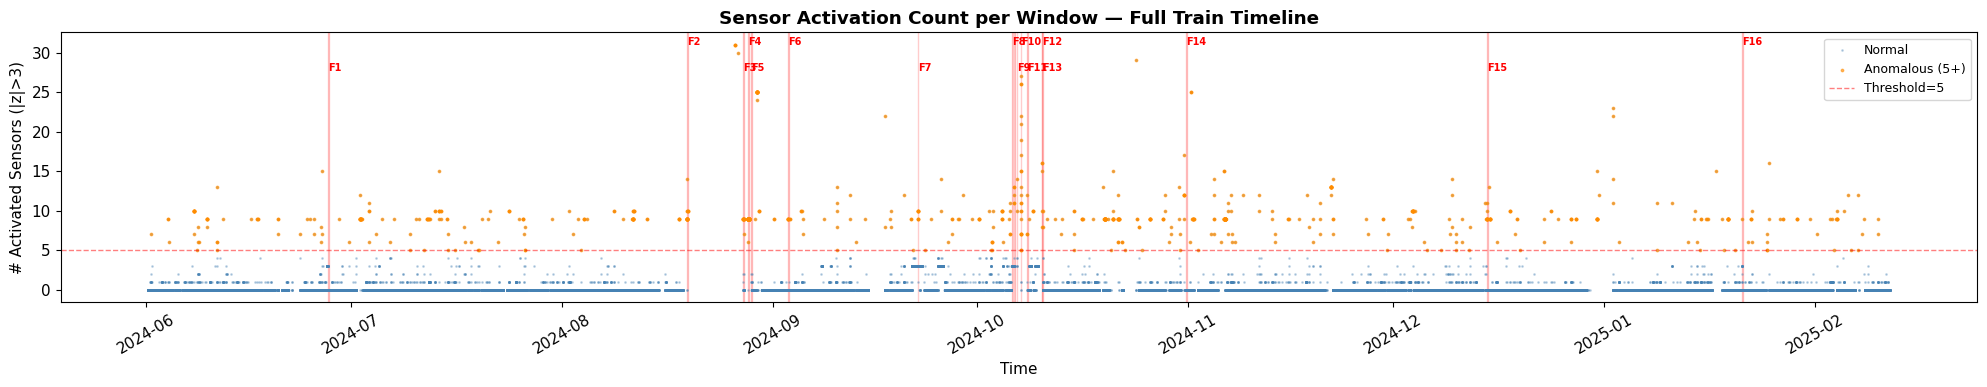

In [7]:
# Timeline plot: activated sensor count over time, with failure events overlaid
fig, ax = plt.subplots(figsize=(20, 4))

ax.scatter(win_df['win_start'], win_df['n_activated'], s=1, alpha=0.3, c='steelblue', label='Normal')
ax.scatter(anom['win_start'], anom['n_activated'], s=3, alpha=0.6, c='darkorange', label=f'Anomalous ({MIN_ACTIVATED}+)')

# Overlay failure events
for idx, ev in train_events.iterrows():
    ax.axvspan(ev['start'], ev['end'], color='red', alpha=0.2, zorder=0)
    ax.text(ev['start'], ax.get_ylim()[1] * 0.95 if idx % 2 == 0 else ax.get_ylim()[1] * 0.85,
            f'F{idx}', fontsize=7, color='red', fontweight='bold')

ax.axhline(MIN_ACTIVATED, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Threshold={MIN_ACTIVATED}')
ax.set_xlabel('Time')
ax.set_ylabel('# Activated Sensors (|z|>3)')
ax.set_title('Sensor Activation Count per Window — Full Train Timeline', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [8]:
# Precursor analysis: anomalous windows in the hours BEFORE each failure onset
LEAD_HOURS = [1, 2, 4, 6, 12, 24]

print('=== Anomalous windows preceding failure events ===')
print(f'{"Event":>5} {"Type":>22} {"Onset":>20}', end='')
for h in LEAD_HOURS:
    print(f' {h}h', end='')
print()

for idx, ev in train_events.iterrows():
    print(f'{idx:>5} {ev["failure_type"][:22]:>22} {str(ev["start"])[:19]:>20}', end='')
    for h in LEAD_HOURS:
        t_start = ev['start'] - pd.Timedelta(hours=h)
        pre_wins = win_df[(win_df['win_start'] >= t_start) & (win_df['win_end'] <= ev['start'])
                          & ~win_df['has_failure'] & ~win_df['has_maintenance']]
        n_pre_anom = pre_wins['is_anomaly'].sum()
        n_pre = len(pre_wins)
        pct = f'{100*n_pre_anom/n_pre:.0f}%' if n_pre > 0 else '-'
        print(f' {n_pre_anom:>2}/{n_pre:<3}', end='')
    print()

=== Anomalous windows preceding failure events ===
Event                   Type                Onset 1h 2h 4h 6h 12h 24h
    1   Brake System Failure  2024-06-27 15:47:30  0/7    0/17   0/38   0/45   0/82   4/167
    2   Brake System Failure  2024-08-19 10:37:51  4/4    5/5   17/19  17/19  17/19  17/99 
    3 Leveling System Failur  2024-08-27 15:58:43  0/0    0/0    0/0    0/0    0/0    1/1  
    4 Leveling System Failur  2024-08-28 06:39:39  0/0    0/0    0/0    0/0    0/0    0/0  
    5 Leveling System Failur  2024-08-28 19:51:57  0/0    0/0    0/0    0/0    0/0    0/0  
    6   Brake System Failure  2024-09-03 05:04:00  6/9    6/16   6/16   6/16   6/69   6/192
    7   Brake System Failure  2024-09-22 05:49:43  0/9    0/20   0/39   0/40   0/102  1/225
    8   Brake System Failure  2024-10-06 02:04:15  0/0    0/0    0/19   0/40   5/102  5/198
    9   Brake System Failure  2024-10-06 20:44:32  0/0    0/0    0/0    0/0    0/0    0/33 
   10   Brake System Failure  2024-10-07 08:41:44  

## 4. Cluster Anomaly Windows by Sensor Activation Profile

Each anomalous window has a **binary activation profile** — which sensors are activated (|z|>3).  
We cluster these profiles to discover **recurring anomaly patterns**: groups of sensors that tend to activate together.

Method: **Hierarchical clustering** (Ward linkage) on the binary activation matrix of anomalous windows.  
We also exclude maintenance windows from clustering — we only want to learn patterns from normal operation + failure precursors.

In [9]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist

# Filter: anomalous windows, excluding maintenance
anom_mask = win_df['is_anomaly'] & ~win_df['has_maintenance']
anom_idx = win_df.index[anom_mask]
print(f'Anomalous windows for clustering (excl. maintenance): {len(anom_idx):,}')

# Build binary activation matrix for anomalous windows
act_matrix = (np.abs(zscore_df.loc[anom_idx].values) > ZSCORE_THRESHOLD).astype(np.float64)
print(f'Activation matrix shape: {act_matrix.shape}')

# Remove sensors that are NEVER activated across any anomalous window (reduces noise)
sensor_ever_active = act_matrix.sum(axis=0) > 0
n_active_sensors = sensor_ever_active.sum()
active_sensor_names = [sensor_cols[i] for i in range(len(sensor_cols)) if sensor_ever_active[i]]
act_matrix_filtered = act_matrix[:, sensor_ever_active]
print(f'Sensors ever activated in anomalous windows: {n_active_sensors} / {len(sensor_cols)}')

# Hierarchical clustering (Ward linkage on Jaccard distance)
dist = pdist(act_matrix_filtered, metric='jaccard')
Z = linkage(dist, method='ward')
print('Linkage computed.')

Anomalous windows for clustering (excl. maintenance): 550
Activation matrix shape: (550, 101)
Sensors ever activated in anomalous windows: 35 / 101
Linkage computed.


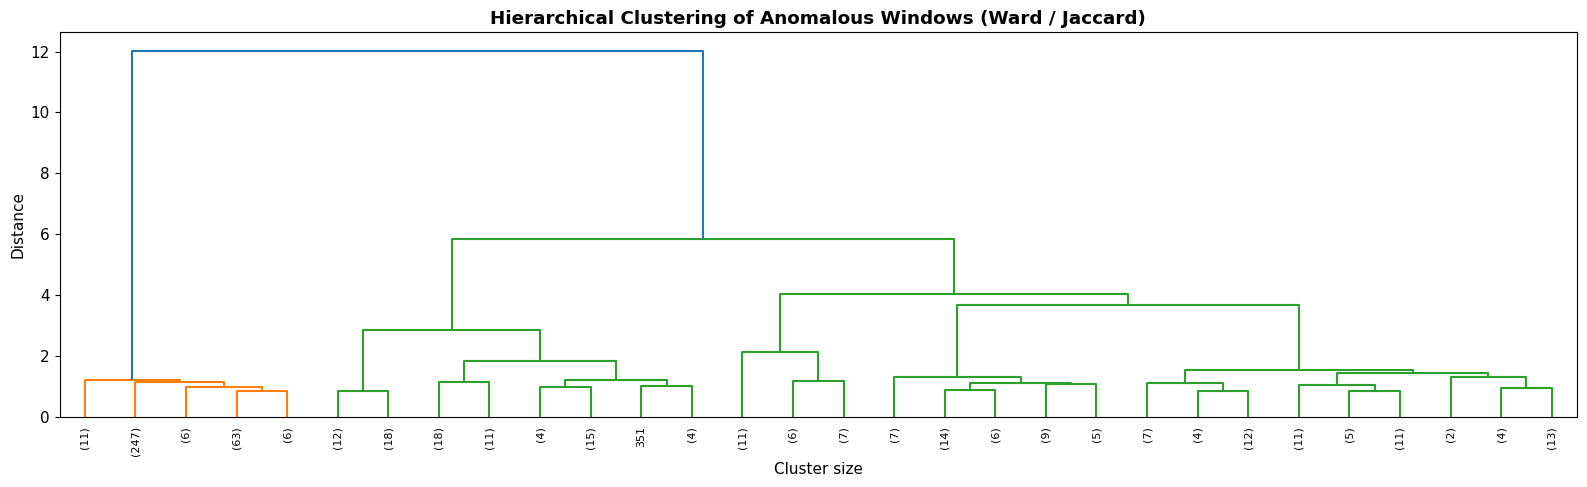


Silhouette scores for different k:
  k=2: silhouette=0.633
  k=3: silhouette=0.654
  k=4: silhouette=0.677
  k=5: silhouette=0.685
  k=6: silhouette=0.688
  k=7: silhouette=0.695
  k=8: silhouette=0.691


In [10]:
# Dendrogram to choose k
fig, ax = plt.subplots(figsize=(16, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Hierarchical Clustering of Anomalous Windows (Ward / Jaccard)', fontweight='bold')
ax.set_xlabel('Cluster size')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Try different k values and show silhouette scores
from sklearn.metrics import silhouette_score

print('\nSilhouette scores for different k:')
for k in range(2, 9):
    labels = fcluster(Z, t=k, criterion='maxclust')
    if len(set(labels)) < 2:
        continue
    sil = silhouette_score(act_matrix_filtered, labels, metric='jaccard', sample_size=min(5000, len(labels)))
    print(f'  k={k}: silhouette={sil:.3f}')

In [11]:
# Choose k based on silhouette — adjust after inspecting results above
# Using k=4 as starting point (same as previous analysis)
K = 4
cluster_labels = fcluster(Z, t=K, criterion='maxclust')
win_df.loc[anom_idx, 'cluster'] = cluster_labels
win_df['cluster'] = win_df['cluster'].fillna(0).astype(int)  # 0 = not anomalous

print(f'Clustering with k={K}')
print(f'\nCluster sizes:')
for c in range(1, K+1):
    n = (cluster_labels == c).sum()
    print(f'  Cluster {c}: {n:,} windows')

# Per-cluster: fraction that overlap with failure
print(f'\n{"Cluster":>8} {"Size":>6} {"In Failure":>12} {"Before Fail":>12} {"Normal":>8}')
for c in range(1, K+1):
    c_mask = win_df['cluster'] == c
    c_df = win_df[c_mask]
    n_c = len(c_df)
    n_fail = c_df['has_failure'].sum()
    
    # Count windows within 6h before a failure
    n_pre = 0
    for _, ev in train_events.iterrows():
        pre_start = ev['start'] - pd.Timedelta(hours=6.2)
        n_pre += ((c_df['win_start'] >= pre_start) & (c_df['win_end'] <= ev['start']) 
                  & ~c_df['has_failure']).sum()
    
    n_norm = n_c - n_fail - n_pre
    print(f'{c:>8} {n_c:>6,} {n_fail:>8,} ({100*n_fail/n_c:4.1f}%) '
          f'{n_pre:>5,} ({100*n_pre/n_c:4.1f}%) {n_norm:>5,} ({100*n_norm/n_c:4.1f}%)')

Clustering with k=4

Cluster sizes:
  Cluster 1: 333 windows
  Cluster 2: 83 windows
  Cluster 3: 24 windows
  Cluster 4: 110 windows

 Cluster   Size   In Failure  Before Fail   Normal
       1    333       34 (10.2%)    23 ( 6.9%)   276 (82.9%)
       2     83        9 (10.8%)     2 ( 2.4%)    72 (86.7%)
       3     24       18 (75.0%)     0 ( 0.0%)     6 (25.0%)
       4    110        0 ( 0.0%)     0 ( 0.0%)   110 (100.0%)


## 5. Pattern Analysis & Subsystem Mapping

For each cluster, identify:
- **Which sensors** activate most frequently (the cluster's "signature")
- **Which subsystems** are involved
- **Relationship to failures** (precursor vs. coincidental)

In [12]:
# Per-cluster sensor activation frequency
# For each cluster, compute how often each sensor is activated (fraction of cluster windows)
print('=== Cluster Sensor Activation Profiles ===\n')

cluster_profiles = {}
for c in range(1, K+1):
    c_idx = anom_idx[cluster_labels == c]
    c_act = (np.abs(zscore_df.loc[c_idx].values) > ZSCORE_THRESHOLD).astype(float)
    freq = c_act.mean(axis=0)  # fraction of windows where sensor is activated
    
    profile = pd.Series(freq, index=sensor_cols).sort_values(ascending=False)
    cluster_profiles[c] = profile
    
    # Show top activated sensors
    top = profile[profile > 0.3]  # sensors activated in >30% of cluster windows
    
    # Subsystem breakdown
    ss_counts = pd.Series([get_subsystem(s) for s in top.index]).value_counts()
    
    print(f'--- Cluster {c} ({(cluster_labels == c).sum():,} windows) ---')
    print(f'Subsystems: {dict(ss_counts)}')
    print(f'Sensors activated in >30% of windows ({len(top)}):')
    for s, f in top.items():
        print(f'  {f:5.1%}  [{get_subsystem(s):8s}]  {s}')
    print()

=== Cluster Sensor Activation Profiles ===

--- Cluster 1 (333 windows) ---
Subsystems: {'Brake': np.int64(9)}
Sensors activated in >30% of windows (9):
  100.0%  [Brake   ]  MW4_SPRING_BRAKE_PRESSURE_BOGIE2
  100.0%  [Brake   ]  MW2_SPRING_BRAKE_PRESSURE_BOGIE2
  100.0%  [Brake   ]  MW2_SPRING_BRAKE_PRESSURE_BOGIE1
  100.0%  [Brake   ]  MW1_SPRING_BRAKE_PRESSURE_BOGIE1
  100.0%  [Brake   ]  CW2_SPRING_BRAKE_PRESSURE_BOGIE2
  99.7%  [Brake   ]  CW1_SPRING_BRAKE_PRESSURE_BOGIE2
  99.4%  [Brake   ]  MW3_SPRING_BRAKE_PRESSURE_BOGIE1
  96.4%  [Brake   ]  MW4_SPRING_BRAKE_PRESSURE_BOGIE1
  96.1%  [Brake   ]  MW1_SPRING_BRAKE_PRESSURE_BOGIE2

--- Cluster 2 (83 windows) ---
Subsystems: {'Brake': np.int64(6), 'Leveling': np.int64(5), 'APU': np.int64(2)}
Sensors activated in >30% of windows (13):
  98.8%  [APU     ]  CW1_MAIN_RESERVOIR_PRESSURE
  98.8%  [APU     ]  CW2_MAIN_RESERVOIR_PRESSURE
  95.2%  [Leveling]  MW3_LOAD_SIGNAL
  94.0%  [Leveling]  MW1_LOAD_SIGNAL
  92.8%  [Leveling]  CW1_LOAD

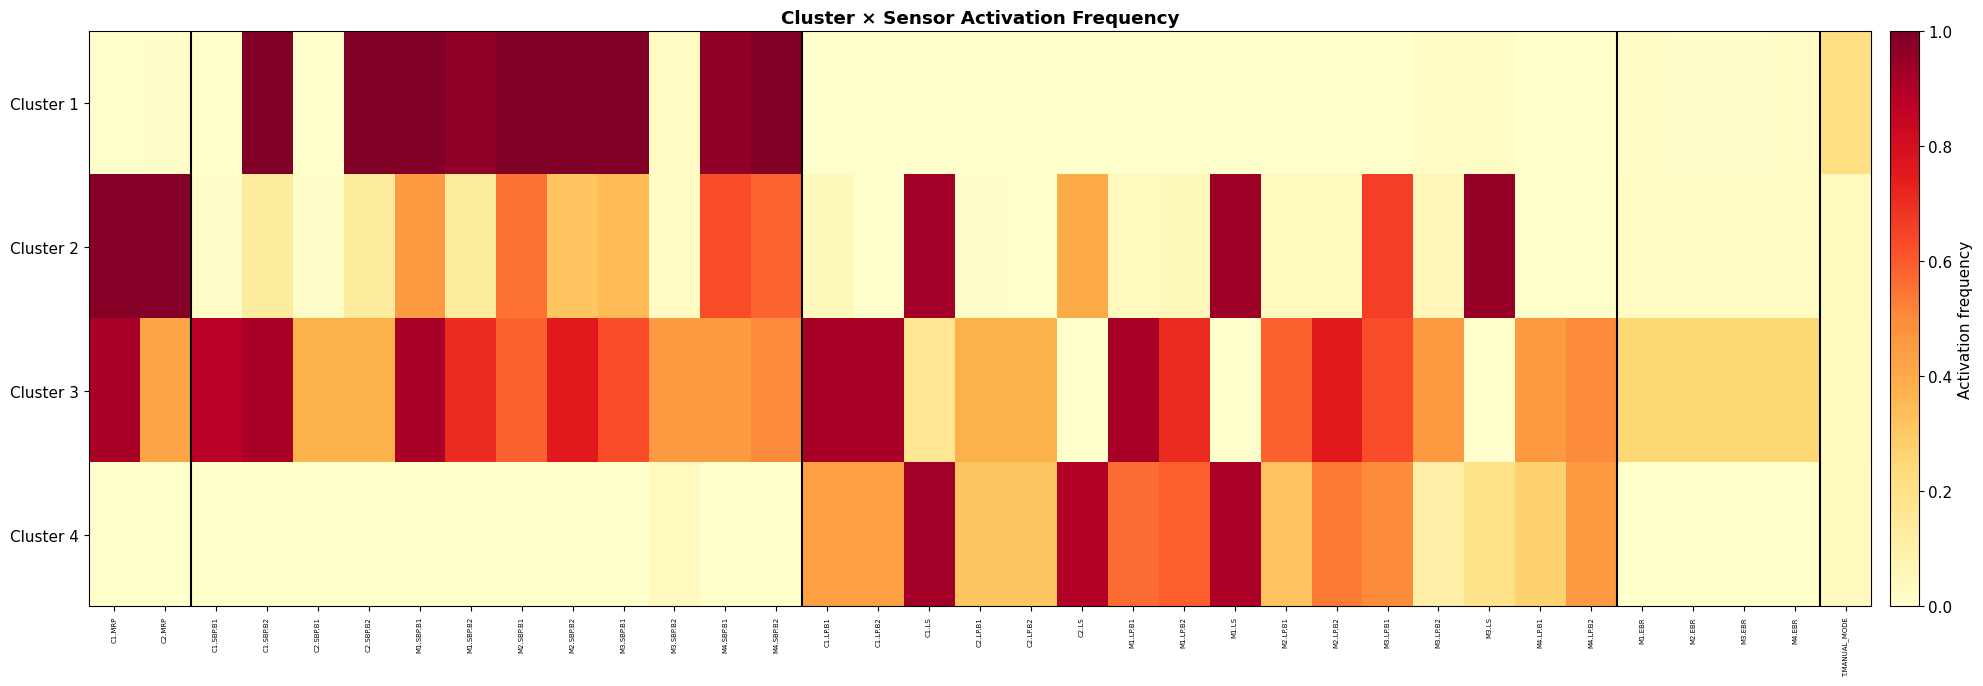

In [13]:
# Heatmap: cluster × sensor activation frequency
fig, ax = plt.subplots(figsize=(20, K * 1.5 + 1))

# Build matrix: rows = clusters, cols = sensors (only ever-active ones)
heat_data = np.zeros((K, len(active_sensor_names)))
for c in range(1, K+1):
    for j, s in enumerate(active_sensor_names):
        heat_data[c-1, j] = cluster_profiles[c].get(s, 0)

# Sort sensors by subsystem for grouping
ss_order = ['APU', 'Brake', 'Leveling', 'Traction', 'Context']
sorted_sensor_idx = sorted(range(len(active_sensor_names)),
                           key=lambda i: (ss_order.index(get_subsystem(active_sensor_names[i]))
                                          if get_subsystem(active_sensor_names[i]) in ss_order else 99,
                                          active_sensor_names[i]))
sorted_sensors = [active_sensor_names[i] for i in sorted_sensor_idx]
heat_sorted = heat_data[:, sorted_sensor_idx]

im = ax.imshow(heat_sorted, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Cluster {c}' for c in range(1, K+1)])

# Abbreviated sensor labels
def short_name(s):
    s = s.replace('CW1_','C1.').replace('CW2_','C2.')
    s = s.replace('MW1_','M1.').replace('MW2_','M2.').replace('MW3_','M3.').replace('MW4_','M4.')
    s = s.replace('_BOGIE1','.B1').replace('_BOGIE2','.B2')
    s = s.replace('SPRING_BRAKE_PRESSURE','SBP').replace('BRAKE_CYLINDER_PRESSURE','BCP')
    s = s.replace('PROPORTIONAL_VALVE_PRESSURE','PVP').replace('PNEUMATIC_BRAKING_FORCE','PBF')
    s = s.replace('MAIN_RESERVOIR_PRESSURE','MRP').replace('LOAD_PRESSURE','LP')
    s = s.replace('LOAD_SIGNAL','LS').replace('ENERGY_BRAKING_RESISTANCE','EBR')
    s = s.replace('PROPORTIONAL_VALVE_PRESSURE_AVAILABLE','PVA').replace('PNEUMATIC_BRAKE_ACTIVE','PBA')
    s = s.replace('COMPRESSOR_RUNNING','COMP').replace('SPRING_BRAKE_ACTIVE','SBA')
    s = s.replace('TRAIN_','T.').replace('AMBIENT_TEMPERATURE','AMB_TEMP').replace('BRAKE_SIGNAL','BRK_SIG')
    return s

ax.set_xticks(range(len(sorted_sensors)))
ax.set_xticklabels([short_name(s) for s in sorted_sensors], rotation=90, fontsize=5)

# Draw subsystem boundaries
prev_ss = None
for j, s in enumerate(sorted_sensors):
    ss = get_subsystem(s)
    if ss != prev_ss and prev_ss is not None:
        ax.axvline(j - 0.5, color='black', linewidth=1.5)
    prev_ss = ss

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Activation frequency')
ax.set_title('Cluster × Sensor Activation Frequency', fontweight='bold')
plt.tight_layout()
plt.show()

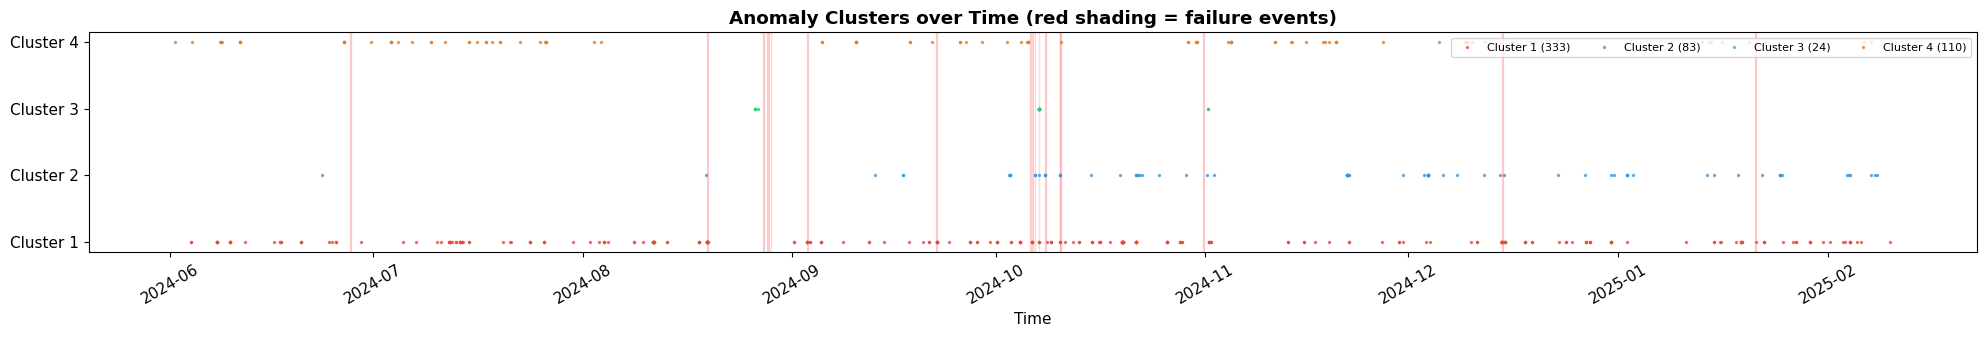

In [14]:
# Timeline of clusters
fig, ax = plt.subplots(figsize=(20, 3.5))

colors = {0: '#e0e0e0', 1: '#e74c3c', 2: '#3498db', 3: '#2ecc71', 4: '#e67e22',
          5: '#9b59b6', 6: '#1abc9c', 7: '#f39c12', 8: '#34495e'}

for c in range(1, K+1):
    c_df = win_df[win_df['cluster'] == c]
    ax.scatter(c_df['win_start'], [c] * len(c_df), s=2, c=colors.get(c, 'grey'), alpha=0.7,
               label=f'Cluster {c} ({len(c_df):,})')

# Failure events
for idx, ev in train_events.iterrows():
    ax.axvspan(ev['start'], ev['end'], color='red', alpha=0.15, zorder=0)

ax.set_yticks(range(1, K+1))
ax.set_yticklabels([f'Cluster {c}' for c in range(1, K+1)])
ax.set_xlabel('Time')
ax.set_title('Anomaly Clusters over Time (red shading = failure events)', fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=K)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Export: Anomaly Patterns & Window Dataset

Save:
1. **Anomaly patterns** — per-cluster sensor activation profiles (for expert verification & feature group definitions)
2. **Window dataset** — all windows with z-scores, activation counts, and cluster labels (for downstream modeling)

In [15]:
# 1. Export per-cluster sensor profiles
pattern_rows = []
for c in range(1, K+1):
    profile = cluster_profiles[c]
    for sensor, freq in profile.items():
        if freq > 0.1:  # only sensors activated in >10% of cluster windows
            pattern_rows.append({
                'cluster': c,
                'sensor': sensor,
                'subsystem': get_subsystem(sensor),
                'activation_freq': round(freq, 4),
            })

patterns_df = pd.DataFrame(pattern_rows)
patterns_path = os.path.join('..', 'outputs', 'anomaly_patterns.csv')
patterns_df.to_csv(patterns_path, index=False)
print(f'Saved {len(patterns_df)} sensor-cluster entries to {patterns_path}')

# Summary per cluster
print('\n=== Pattern Summary ===')
for c in range(1, K+1):
    c_pat = patterns_df[patterns_df['cluster'] == c]
    ss_list = c_pat.groupby('subsystem')['sensor'].count().to_dict()
    top_sensors = c_pat.nlargest(5, 'activation_freq')[['sensor', 'activation_freq']]
    n_wins = (cluster_labels == c).sum()
    print(f'\nCluster {c} ({n_wins:,} windows)')
    print(f'  Subsystems: {ss_list}')
    print(f'  Top 5 sensors:')
    for _, r in top_sensors.iterrows():
        print(f'    {r["activation_freq"]:5.1%}  {r["sensor"]}')

# 2. Export window dataset
export_cols = ['win_start', 'win_end', 'n_rows', 'has_failure', 'has_maintenance',
               'failure_type', 'n_activated', 'max_abs_z', 'mean_abs_z', 'is_anomaly', 'cluster']
win_export = win_df[export_cols].copy()
win_path = os.path.join('..', 'outputs', 'anomaly_windows.csv')
win_export.to_csv(win_path, index=False)
print(f'\nSaved {len(win_export):,} windows to {win_path}')
print(f'  Anomalous: {win_export["is_anomaly"].sum():,}')
print(f'  Normal:    {(~win_export["is_anomaly"]).sum():,}')

Saved 73 sensor-cluster entries to ..\outputs\anomaly_patterns.csv

=== Pattern Summary ===

Cluster 1 (333 windows)
  Subsystems: {'Brake': 9, 'Context': 1}
  Top 5 sensors:
    100.0%  MW4_SPRING_BRAKE_PRESSURE_BOGIE2
    100.0%  MW2_SPRING_BRAKE_PRESSURE_BOGIE2
    100.0%  MW2_SPRING_BRAKE_PRESSURE_BOGIE1
    100.0%  MW1_SPRING_BRAKE_PRESSURE_BOGIE1
    100.0%  CW2_SPRING_BRAKE_PRESSURE_BOGIE2

Cluster 2 (83 windows)
  Subsystems: {'APU': 2, 'Brake': 9, 'Leveling': 5}
  Top 5 sensors:
    98.8%  CW1_MAIN_RESERVOIR_PRESSURE
    98.8%  CW2_MAIN_RESERVOIR_PRESSURE
    95.2%  MW3_LOAD_SIGNAL
    94.0%  MW1_LOAD_SIGNAL
    92.8%  CW1_LOAD_SIGNAL

Cluster 3 (24 windows)
  Subsystems: {'APU': 2, 'Brake': 12, 'Leveling': 13, 'Traction': 4}
  Top 5 sensors:
    91.7%  CW1_MAIN_RESERVOIR_PRESSURE
    91.7%  CW1_SPRING_BRAKE_PRESSURE_BOGIE2
    91.7%  MW1_SPRING_BRAKE_PRESSURE_BOGIE1
    91.7%  MW1_LOAD_PRESSURE_BOGIE1
    91.7%  CW1_LOAD_PRESSURE_BOGIE1

Cluster 4 (110 windows)
  Subsystems: 